# Error scaling analysis

Figures for Section 5 (simplified Henry problem) and Appendix I (classical Henry problem), computed from the
validation predictions `predictions/scenario_XXX_<size>.npz` written by `train_fno_sweep.py`. Choose the dataset
with `DATASET` below. Sections 1–4 are diagnostic plots; section 5 produces the paper figures.

In [26]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import brentq, curve_fit

plt.style.use("default")

# "simplified": simplified Henry problem (Section 5); "classical": classical Henry problem (Appendix I).
DATASET = "simplified"
CONFIGS = {
    "simplified": {
        "results_dir": "~/Projects/groundwater/results/fno_simple_henry_sweep",
        "data_dir": "~/Projects/groundwater/data/simple_henry_data",
        "run_name": "grid_scenarios_ic_random_skip2_20x40",
        "dt": 0.04,                          # T = 1.0 d, 25 outputs
        "single_scenario": (7e-5, 0.003),    # (beta_C, D_C) for Fig. 3
        "snapshot_scenario": (2e-5, 0.01),   # (beta_C, D_C) for Fig. 7
    },
    "classical": {
        "results_dir": "~/Projects/groundwater/results/fno_forced_henry_sweep",
        "data_dir": "~/Projects/groundwater/data/henry_forced_data",
        "run_name": "grid_scenarios_forced_random_skip2_20x40",
        "dt": 0.01,                          # T = 0.25 d, 25 outputs
        "single_scenario": (7e-4, 0.1),      # Fig. 13
        "snapshot_scenario": (7e-4, 0.3),    # Fig. 10
    },
}
cfg = CONFIGS[DATASET]

results_path = Path(cfg["results_dir"]).expanduser() / cfg["run_name"]
data_path = Path(cfg["data_dir"]).expanduser() / cfg["run_name"]
prediction_npz_dir = results_path / "predictions"
fig_dir = results_path / "figures" / "final"
fig_dir.mkdir(parents=True, exist_ok=True)

DX = DZ = 0.05
DT = cfg["dt"]

N_COLS = 4                 # scenario grid columns
EXCLUDE_SCENARIOS = [1, 2, 3, 4]     # dropped from every plot and fit
RECOMPUTE = False          # set True to ignore the cached metrics CSV
metrics_cache = results_path / f"npz_metrics_dt{DT:g}.csv"   # keyed on DT: changing DT recomputes

In [27]:
# ---- Metadata: model sizes and scenario parameters ----
sweep_df = pd.read_csv(results_path / "sweep_results.csv")
model_sizes = (
    sweep_df[["model_size_label", "total_params"]]
    .drop_duplicates()
    .sort_values("total_params")
    .reset_index(drop=True)
)
param_counts = model_sizes.set_index("model_size_label")["total_params"].to_dict()

manifest = json.load(open(data_path / "manifest.json"))["scenarios"]
scenarios_df = pd.DataFrame(manifest)[["scenario_index", "beta_c", "diffc"]]

model_sizes

,model_size_label,total_params
0,tiny,10070
1,small,67626
2,medium,1043826
3,large,8871906
4,huge,30453330


## Metrics

In [28]:
def spatial_norms_sq(u):
    """Per-run (L^inf_t L^2_x)^2 and int_t ||grad u||_2^2 dt for u of shape (N, T, Z, X)."""
    area = DZ * DX
    l2_sq_space = np.sum(u ** 2, axis=(2, 3)) * area
    gz, gx = np.gradient(u, DZ, DX, axis=(2, 3))
    grad_sq_space = np.sum(gz ** 2 + gx ** 2, axis=(2, 3)) * area
    return np.max(l2_sq_space, axis=1), np.sum(grad_sq_space, axis=1) * DT


def head_sup_h1_norm(u):
    """Per-run sup_t ||u(t)||_{H^1} for u of shape (N, T, Z, X)."""
    area = DZ * DX
    l2_sq_space = np.sum(u ** 2, axis=(2, 3)) * area
    gz, gx = np.gradient(u, DZ, DX, axis=(2, 3))
    grad_sq_space = np.sum(gz ** 2 + gx ** 2, axis=(2, 3)) * area
    return np.max(np.sqrt(l2_sq_space + grad_sq_space), axis=1)


def rel_l2(target, pred):
    """Per-run relative L2 error over all of (T, Z, X); returns shape (N,)."""
    n = target.shape[0]
    diff = np.linalg.norm((pred - target).reshape(n, -1), axis=1)
    return diff / (np.linalg.norm(target.reshape(n, -1), axis=1) + 1e-12)


def compute_metrics(targets, preds):
    """All metrics for one (scenario, model) pair, each averaged over validation runs.

    Concentration norm  ||C||_{C_T}^2 = (L^inf L^2)^2 + int ||grad C||^2 dt.
    The two concentration components are normalised by the *full* true-solution norm, so
    conc_linf_l2^2 + conc_grad^2 = conc_norm^2.
    Head component is the relative sup_t H^1 norm. total_norm = conc_norm + head_norm.
    """
    t_c, p_c = targets[..., 0].astype(np.float64), preds[..., 0].astype(np.float64)
    t_h, p_h = targets[..., 1].astype(np.float64), preds[..., 1].astype(np.float64)

    linf_d, grad_d = spatial_norms_sq(p_c - t_c)
    linf_t, grad_t = spatial_norms_sq(t_c)
    true_c = np.sqrt(linf_t + grad_t)

    conc_norm = np.sqrt(linf_d + grad_d) / true_c
    head_norm = head_sup_h1_norm(p_h - t_h) / head_sup_h1_norm(t_h)

    return {
        "conc_rel_l2": rel_l2(t_c, p_c).mean(),
        "head_rel_l2": rel_l2(t_h, p_h).mean(),
        "conc_linf_l2": (np.sqrt(linf_d) / true_c).mean(),
        "conc_grad": (np.sqrt(grad_d) / true_c).mean(),
        "head_norm": head_norm.mean(),
        "conc_norm": conc_norm.mean(),
        "total_norm": (conc_norm + head_norm).mean(),
    }

In [29]:
if metrics_cache.exists() and not RECOMPUTE:
    metrics_df = pd.read_csv(metrics_cache)
else:
    rows = []
    for npz_file in sorted(prediction_npz_dir.glob("scenario_*.npz")):
        parts = npz_file.stem.split("_")
        scenario_index, size_label = int(parts[1]), parts[-1]
        with np.load(npz_file) as data:
            targets, preds = data["val_targets"], data["val_preds"]
        rows.append({"scenario_index": scenario_index, "model_size_label": size_label,
                     **compute_metrics(targets, preds)})
        print(f"done {npz_file.name}")
    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(metrics_cache, index=False)

metrics_df = (
    metrics_df
    .merge(scenarios_df, on="scenario_index", how="left")
    .assign(total_params=lambda d: d["model_size_label"].map(param_counts))
    .query("scenario_index not in @EXCLUDE_SCENARIOS")
    .sort_values(["scenario_index", "total_params"])
    .reset_index(drop=True)
)
scenario_indices = sorted(metrics_df["scenario_index"].unique())
metrics_df.head()

,scenario_index,model_size_label,conc_rel_l2,head_rel_l2,conc_linf_l2,conc_grad,head_norm,conc_norm,total_norm,beta_c,diffc,total_params
0,5,tiny,0.216841,0.636335,0.047743,0.295771,0.637558,0.299755,0.937313,0.00002,0.001,10070
1,5,small,0.181805,0.436028,0.031481,0.205788,0.309180,0.208316,0.517496,0.00002,0.001,67626
2,5,medium,0.079717,0.328410,0.013856,0.111046,0.181703,0.112025,0.293728,0.00002,0.001,1043826
3,5,large,0.051299,0.115980,0.008762,0.070825,0.089010,0.071450,0.160459,0.00002,0.001,8871906
4,5,huge,0.033576,0.073508,0.005913,0.048477,0.061957,0.048897,0.110854,0.00002,0.001,30453330


## Plot helpers and theory fits

In [30]:
# Theoretical bound: P(eps) = K * eps^-a * (1 + log(1/eps))^2, a = 16 from theory,
# i.e. log(P/K) = -a log(eps) + 2 log(1 - log(eps)).
THEORY_EXP = 16


def theory_log_P_over_K(eps, exponent=THEORY_EXP):
    log_eps = np.log(eps)
    return -exponent * log_eps + 2 * np.log1p(-log_eps)


def theory_eps_from_P(P, K, exponent=THEORY_EXP):
    """Invert the bound numerically (root-find in log(eps) to avoid overflow)."""
    targets = np.log(np.asarray(P, dtype=float)) - np.log(K)

    def solve(t):
        u = brentq(lambda u: -exponent * u + 2 * np.log1p(-u) - t, -1000.0, 1.0 - 1e-12)
        return np.exp(u)

    return np.vectorize(solve)(targets)


def theory_K_envelope(P, eps, exponent=THEORY_EXP):
    """Smallest K (a fixed) for which the bound lies above every empirical point."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    return np.exp(np.max(np.log(P) - theory_log_P_over_K(eps, exponent)))


def fit_theory_K(P, eps, exponent=THEORY_EXP):
    """Least-squares fit of K only (exponent fixed), in log(eps)."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    log_K0 = np.mean(np.log(P) - theory_log_P_over_K(eps, exponent))

    def model(P, log_K):
        return np.log(theory_eps_from_P(P, np.exp(log_K), exponent))

    popt, _ = curve_fit(model, P, np.log(eps), p0=[log_K0])
    return np.exp(popt[0])


def fit_theory_K_exponent(P, eps):
    """Least-squares fit of (K, a) in log(eps)."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    log_eps = np.log(eps)
    a0, log_K0 = np.polyfit(-log_eps, np.log(P) - 2 * np.log1p(-log_eps), 1)
    a0 = max(a0, 1e-2)

    def model(P, log_K, exponent):
        return np.log(theory_eps_from_P(P, np.exp(log_K), exponent))

    popt, _ = curve_fit(model, P, log_eps, p0=[log_K0, a0],
                        bounds=([-np.inf, 1e-3], [np.inf, np.inf]))
    return np.exp(popt[0]), popt[1]


def plot_theory_overlay(ax, P, eps, show_fixed=True):
    """Overlay the three theory curves; returns the fitted parameters (NaN if a fit fails)."""
    P_grid = np.logspace(np.log10(min(P)), np.log10(max(P)), 200)
    out = {"K_fit_fixed_exp": np.nan, "K_fit": np.nan, "exponent_fit": np.nan, "K_envelope": np.nan}

    try:  # orange: exponent fixed, K fitted
        out["K_fit_fixed_exp"] = fit_theory_K(P, eps)
        if show_fixed:
            ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_fit_fixed_exp"]), color="orange", linestyle="--",
                    label=f"Fit $K$ ($a$={THEORY_EXP}, $K$={out['K_fit_fixed_exp']:.2e})")
    except Exception as exc:
        print(f"  fixed-exponent fit failed: {exc}")

    try:  # green: K and exponent fitted
        out["K_fit"], out["exponent_fit"] = fit_theory_K_exponent(P, eps)
        ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_fit"], out["exponent_fit"]), color="green", linestyle=":",
                label=f"Fit $K, a$ ($a$={out['exponent_fit']:.2f}, $K$={out['K_fit']:.2e})")
    except Exception as exc:
        print(f"  free fit failed: {exc}")

    try:  # red: smallest K for which the curve upper-bounds every point
        out["K_envelope"] = theory_K_envelope(P, eps)
        ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_envelope"]), color="red", linestyle="-.",
                label=f"Bound ($a$={THEORY_EXP}, $K^*$={out['K_envelope']:.2e})")
    except Exception as exc:
        print(f"  envelope failed: {exc}")
    return out


def compute_rayleigh_number(beta_c, diffc):
    K, delta_c, H, eta = 50, 35, 1, 0.35
    return (K * beta_c * delta_c * H) / (eta * diffc)


def scenario_grid(metric, ylabel, title, fname, theory=False, logy=False, paper=False):
    """One subplot per scenario: validation error vs total parameters.

    paper=True gives a compact publication layout: no suptitle (goes in the caption), no orange fit,
    one shared legend, fitted parameters annotated in each panel, shared axes, and a PDF saved next
    to the PNG. Panels are labelled by row ($\\beta_C$, left) and column ($D_C$, top) instead of
    per-panel titles, with $R_a$ in the top-right corner of each panel.
    Returns a DataFrame of fitted theory parameters (one row per scenario) when theory=True.
    """
    n = len(scenario_indices)
    n_rows = math.ceil(n / N_COLS)
    figsize = (3.1 * N_COLS, 1.75 * n_rows + 0.7) if paper else (4 * N_COLS, 2.2 * n_rows + 1)
    fit_rows = []

    with plt.rc_context({"font.size": 10} if paper else {}):
        fig, axes = plt.subplots(n_rows, N_COLS, figsize=figsize, sharex=True, sharey=paper,
                                 constrained_layout=True, squeeze=False)
        for ax in axes.flat[n:]:
            ax.set_visible(False)

        for i, (ax, s) in enumerate(zip(axes.flat, scenario_indices)):
            sub = metrics_df[metrics_df["scenario_index"] == s].sort_values("total_params")
            beta_c, diffc = sub["beta_c"].iloc[0], sub["diffc"].iloc[0]
            Ra = compute_rayleigh_number(beta_c, diffc)
            P, eps = sub["total_params"].to_numpy(), sub[metric].to_numpy()

            ax.plot(P, eps, color="blue", marker="o", label="Empirical")
            if theory:
                fit = plot_theory_overlay(ax, P, eps, show_fixed=not paper)
                fit_rows.append({"scenario_index": s, "beta_c": beta_c, "diffc": diffc, "Ra": Ra, **fit})
                if paper:
                    ax.text(0.04, 0.05,
                            f"$a$={fit['exponent_fit']:.2f}\n$A$={fit['K_fit']:.1e}\n$A^*$={fit['K_envelope']:.1e}",
                            transform=ax.transAxes, fontsize=8.5, va="bottom", ha="left",
                            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9))
                else:
                    ax.legend(fontsize=6)

            on_bottom = (i + N_COLS >= n) if paper else True
            on_left = (i % N_COLS == 0) if paper else True
            if paper:
                if i < N_COLS:
                    ax.set_title(f"$D_C={diffc:g}$", fontsize=11)
                ax.set_ylabel(f"$\\beta_C={beta_c:g}$" if on_left else "", fontsize=10)
                ax.text(0.97, 0.94, f"$R_a$={Ra:.1f}", transform=ax.transAxes, fontsize=9,
                        va="top", ha="right")
                ax.yaxis.set_major_locator(plt.MaxNLocator(4))
            else:
                ax.set_title(f"$\\beta_C={beta_c:g}$, $D_C={diffc:g}$, $R_a={Ra:g}$", fontsize=9)
                ax.set_ylabel(ylabel)
                ax.set_xlabel("Total Parameters")
            ax.set_xscale("log")
            if logy:
                ax.set_yscale("log")
            ax.grid(True, which="both", linestyle="--", linewidth=0.5)
            if paper:
                ax.tick_params(labelbottom=on_bottom, labelleft=on_left)

        if paper:
            handles, _ = axes[0, 0].get_legend_handles_labels()
            fig.supylabel(ylabel, fontsize=12)
            fig.supxlabel("Total Parameters", fontsize=12)
            fig.legend(handles, ["Empirical", "Fit ($A$, $a$ free)", "Bound ($a$=16, $A^*$)"],
                       loc="outside upper center", ncol=3, fontsize=11, frameon=False)
        else:
            fig.suptitle(title, fontsize=13)

        fig.savefig(fig_dir / fname, bbox_inches="tight", dpi=300)
        if paper:
            fig.savefig(fig_dir / Path(fname).with_suffix(".pdf"), bbox_inches="tight")
        plt.show()
        plt.close(fig)
    return pd.DataFrame(fit_rows) if theory else None


## 1. Loss vs epoch (Fig. 6 / Fig. 9)

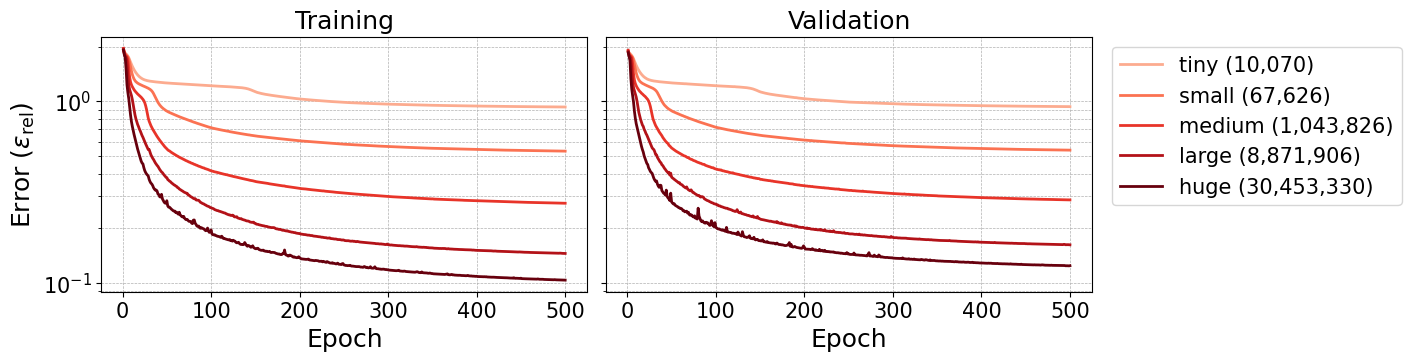

In [31]:
loss_dir = results_path / "figures"
colors = plt.cm.Reds(np.linspace(0.3, 1, len(model_sizes)))
history_panels = [
    ("train_rel_combined_norm_history", "Training"),
    ("val_rel_combined_norm_history", "Validation"),
]

with plt.rc_context({"font.size": 16, "axes.titlesize": 18, "axes.labelsize": 18,
                     "xtick.labelsize": 15, "ytick.labelsize": 15, "legend.fontsize": 15}):
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True, constrained_layout=True)

    for color, (label, params) in zip(colors, model_sizes.itertuples(index=False)):
        files = sorted(loss_dir.glob(f"{label}*_loss_history.json"))
        if not files:
            print(f"no loss history for {label}")
            continue
        histories = [json.load(open(f)) for f in files]

        for ax, (key, title) in zip(axes.flat, history_panels):
            stack = np.array([h[key] for h in histories])   # (n_files, n_epochs)
            epochs = np.arange(1, stack.shape[1] + 1)
            ax.plot(epochs, stack.mean(axis=0), color=color, linewidth=2, label=f"{label} ({params:,})")
            if len(stack) > 1:
                ax.fill_between(epochs, stack.min(axis=0), stack.max(axis=0), color=color, alpha=0.25)
            ax.set_title(title)

    for ax in axes.flat:
        ax.set_xlabel("Epoch")
        ax.set_yscale("log")
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    axes[0].set_ylabel(r"Error ($\varepsilon_{\text{rel}}$)")
    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

    fig.savefig(fig_dir / "loss_vs_epoch.png", bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

## 2. Error scaling per scenario

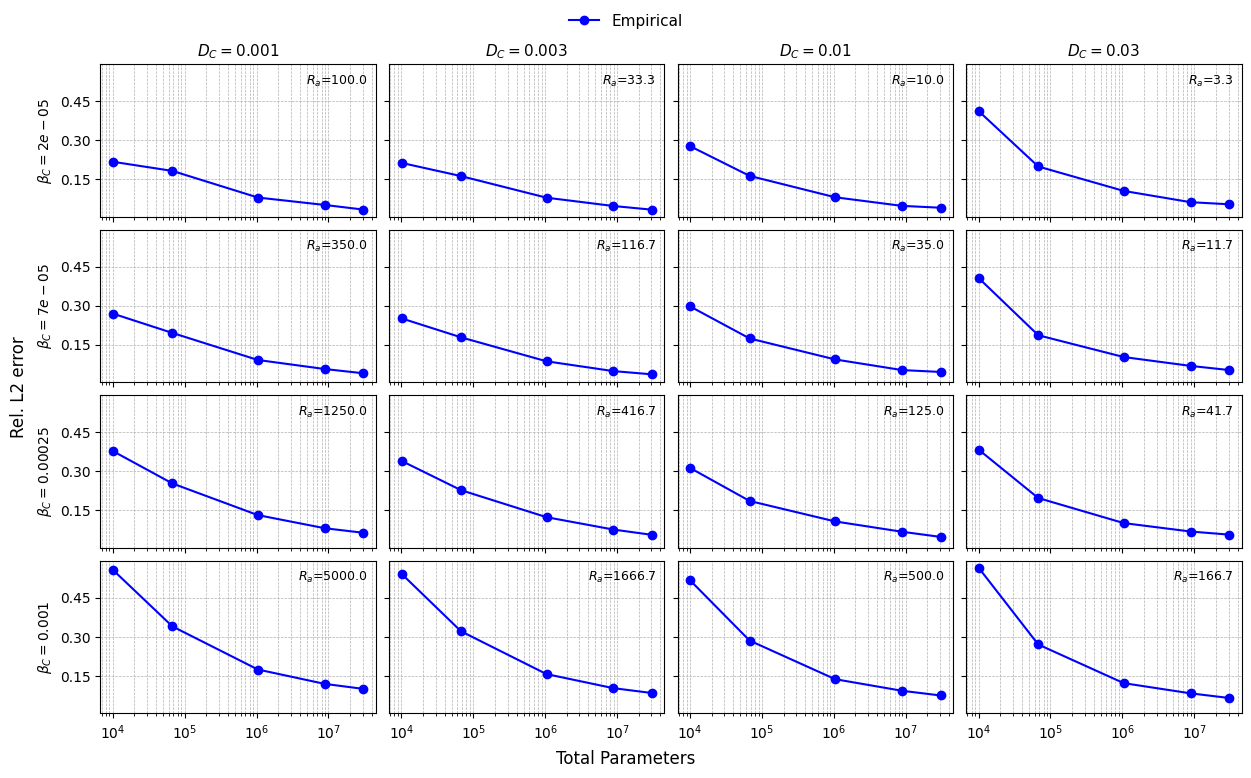

In [32]:
scenario_grid("conc_rel_l2", "Rel. L2 error",
              "Concentration relative L2 error vs model size (validation)",
              "scaling_2a_conc_rel_l2.png", paper=True)

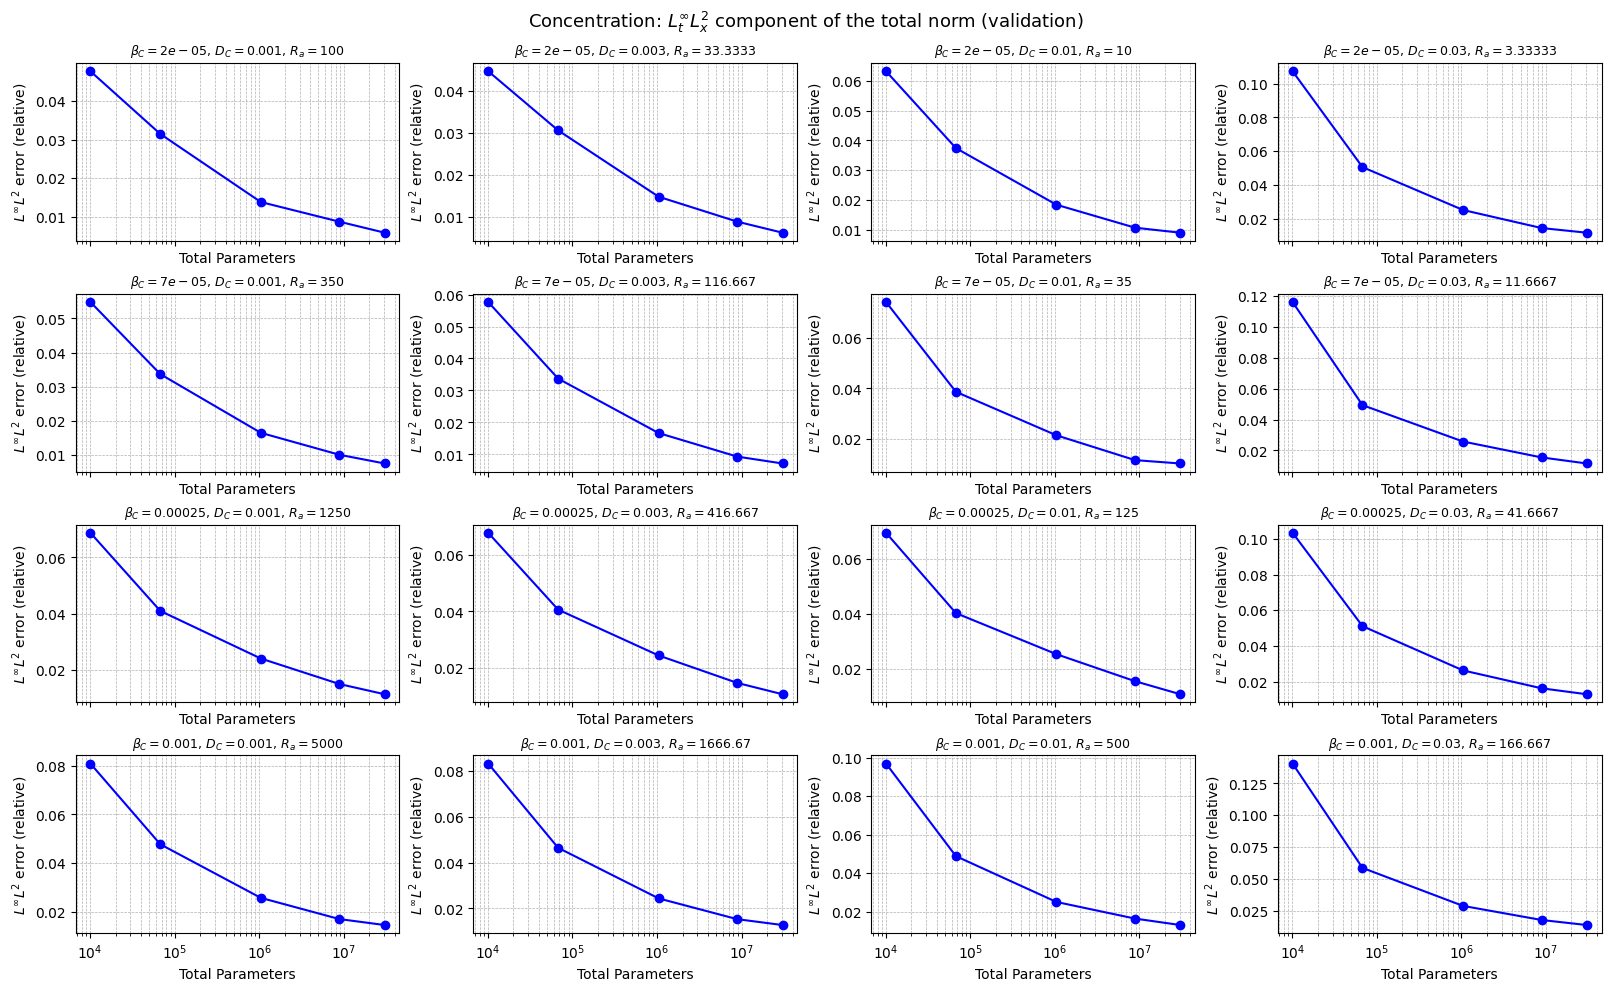

In [33]:
scenario_grid("conc_linf_l2", "$L^\\infty L^2$ error (relative)",
              "Concentration: $L^\\infty_t L^2_x$ component of the total norm (validation)",
              "scaling_2c_conc_linf_l2.png")

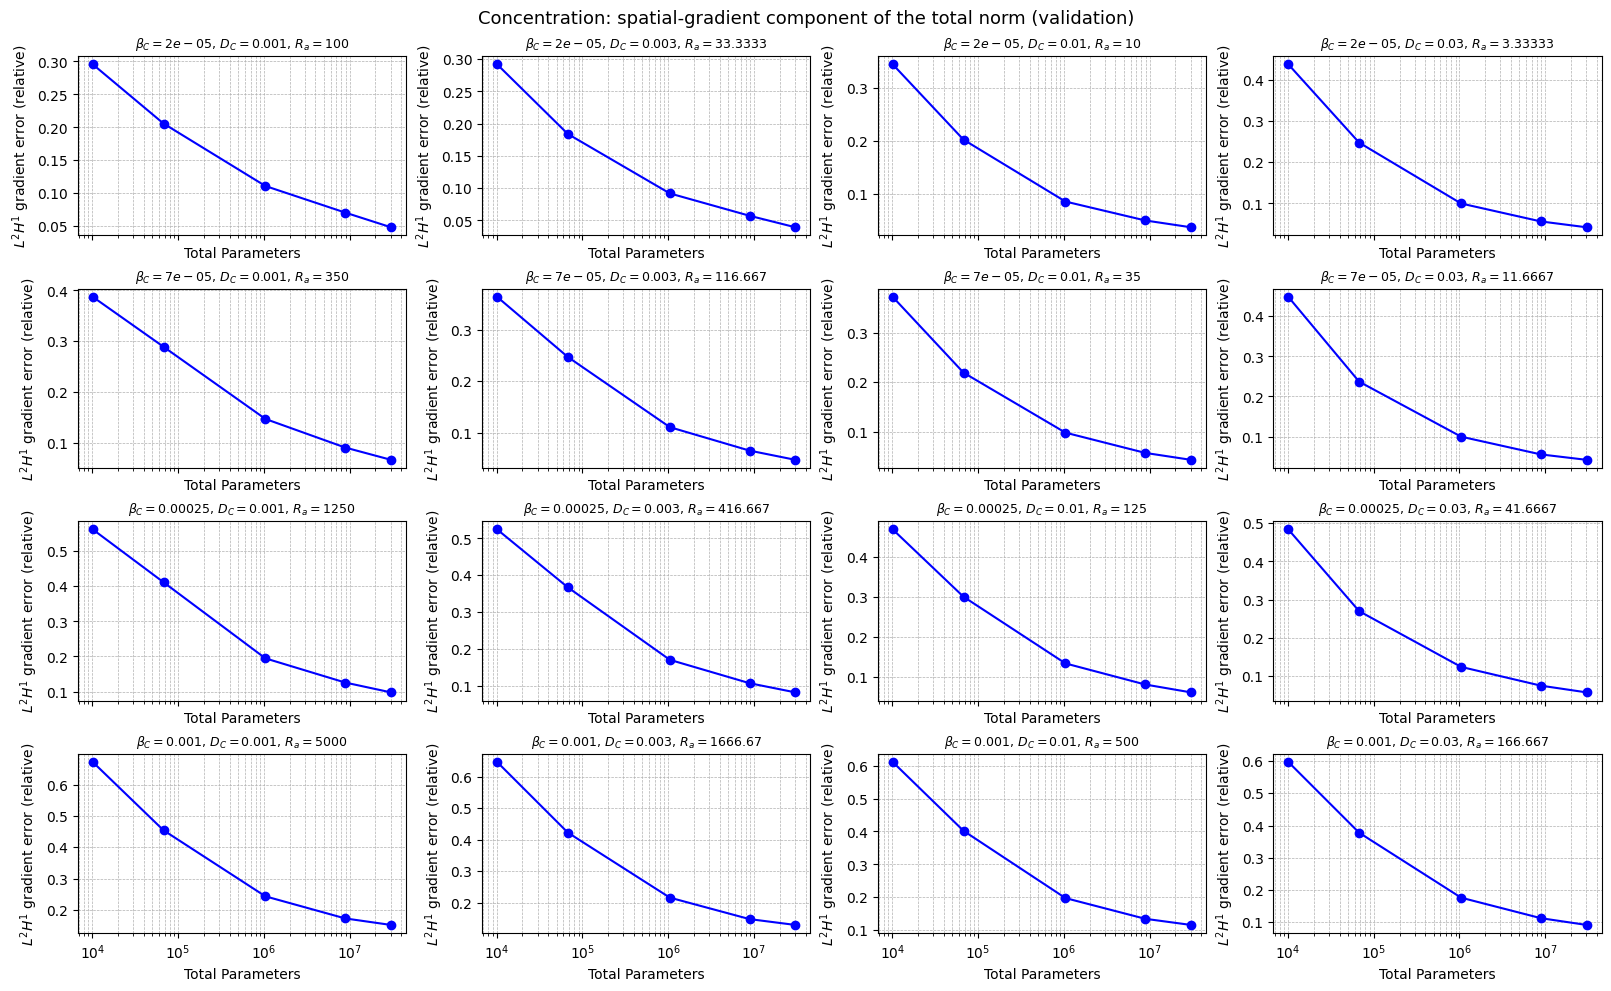

In [34]:
scenario_grid("conc_grad", "$L^2 H^1$ gradient error (relative)",
              "Concentration: spatial-gradient component of the total norm (validation)",
              "scaling_2d_conc_grad.png")

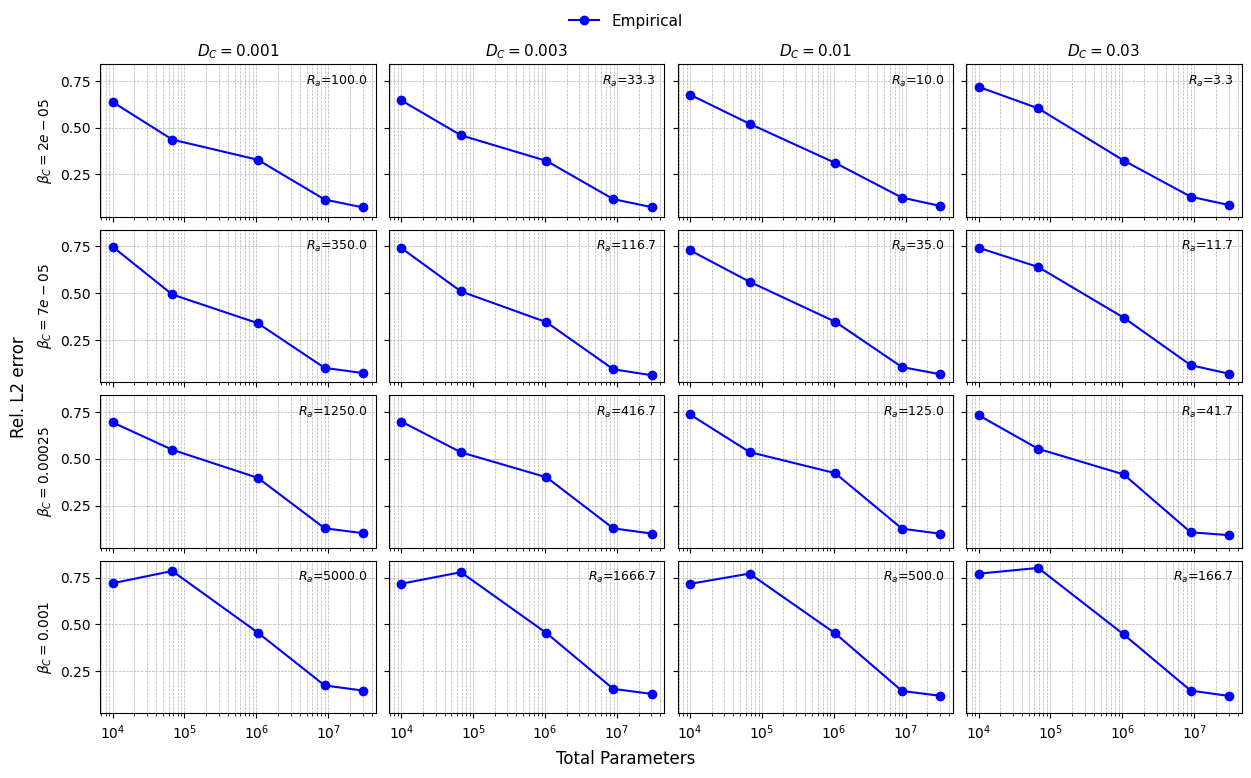

In [35]:
scenario_grid("head_rel_l2", "Rel. L2 error",
              "Hydraulic head relative L2 error vs model size (validation)",
              "scaling_2b_head_rel_l2.png", paper=True)

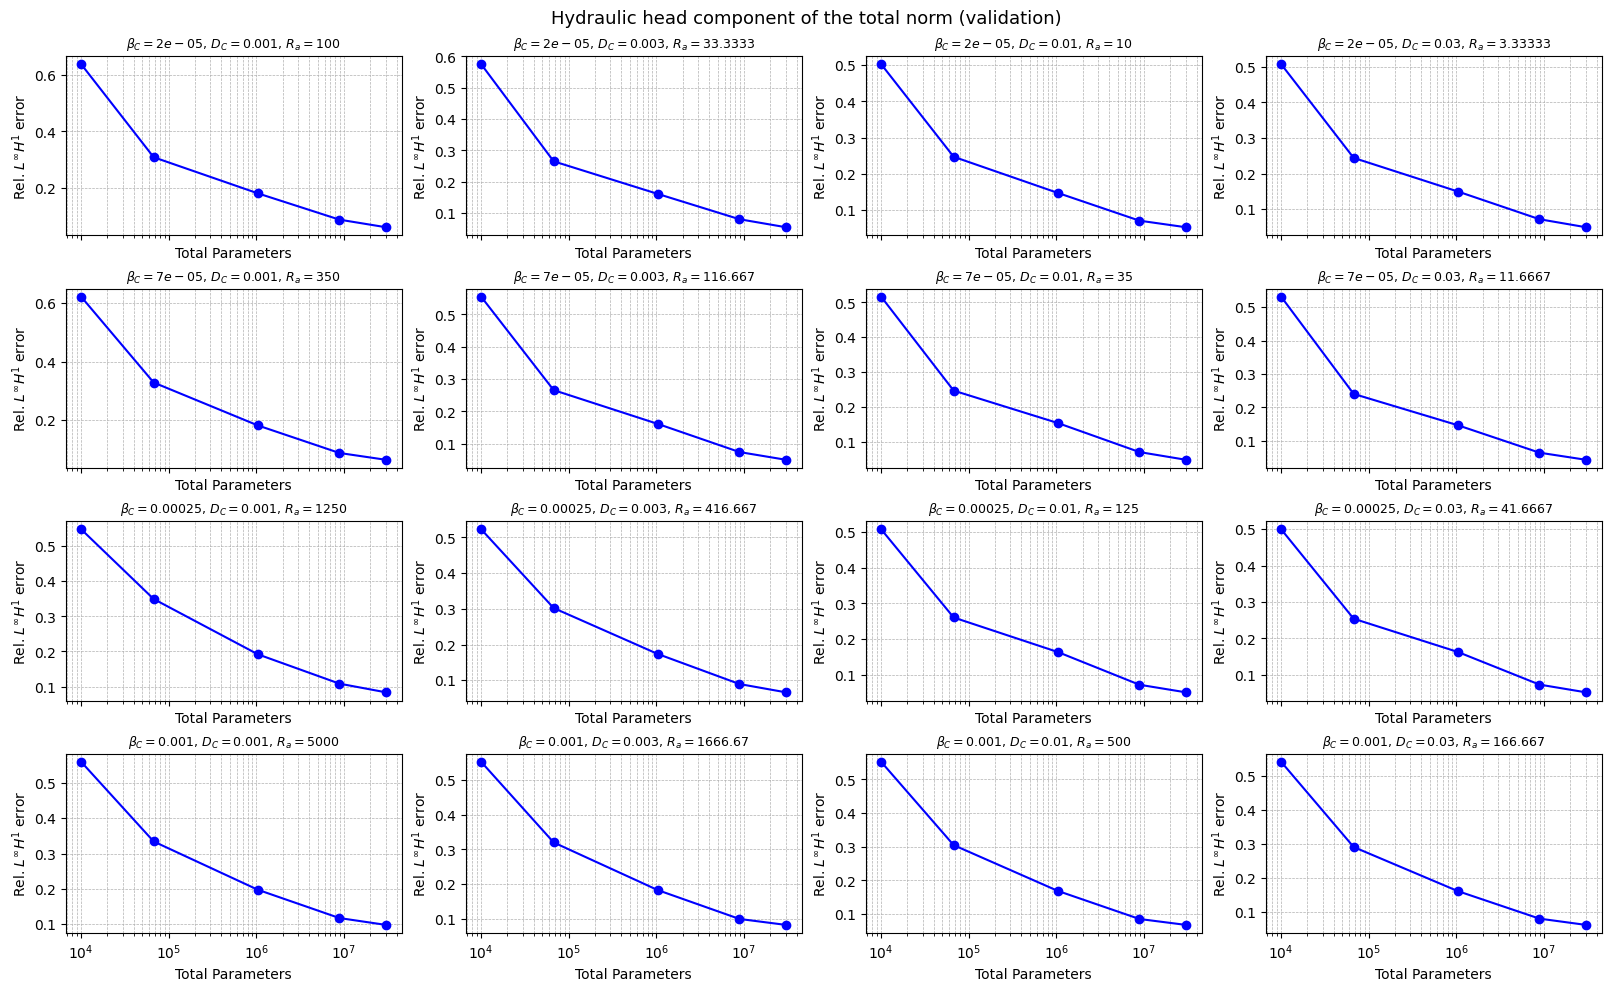

In [36]:
scenario_grid("head_norm", "Rel. $L^\\infty H^1$ error",
              "Hydraulic head component of the total norm (validation)",
              "scaling_2e_head_norm.png")

## 3. Theory fits

Orange: $a=16$, $K$ fitted. Green: $K$ and $a$ fitted. Red: smallest bound constant $K^*$ with $a=16$.

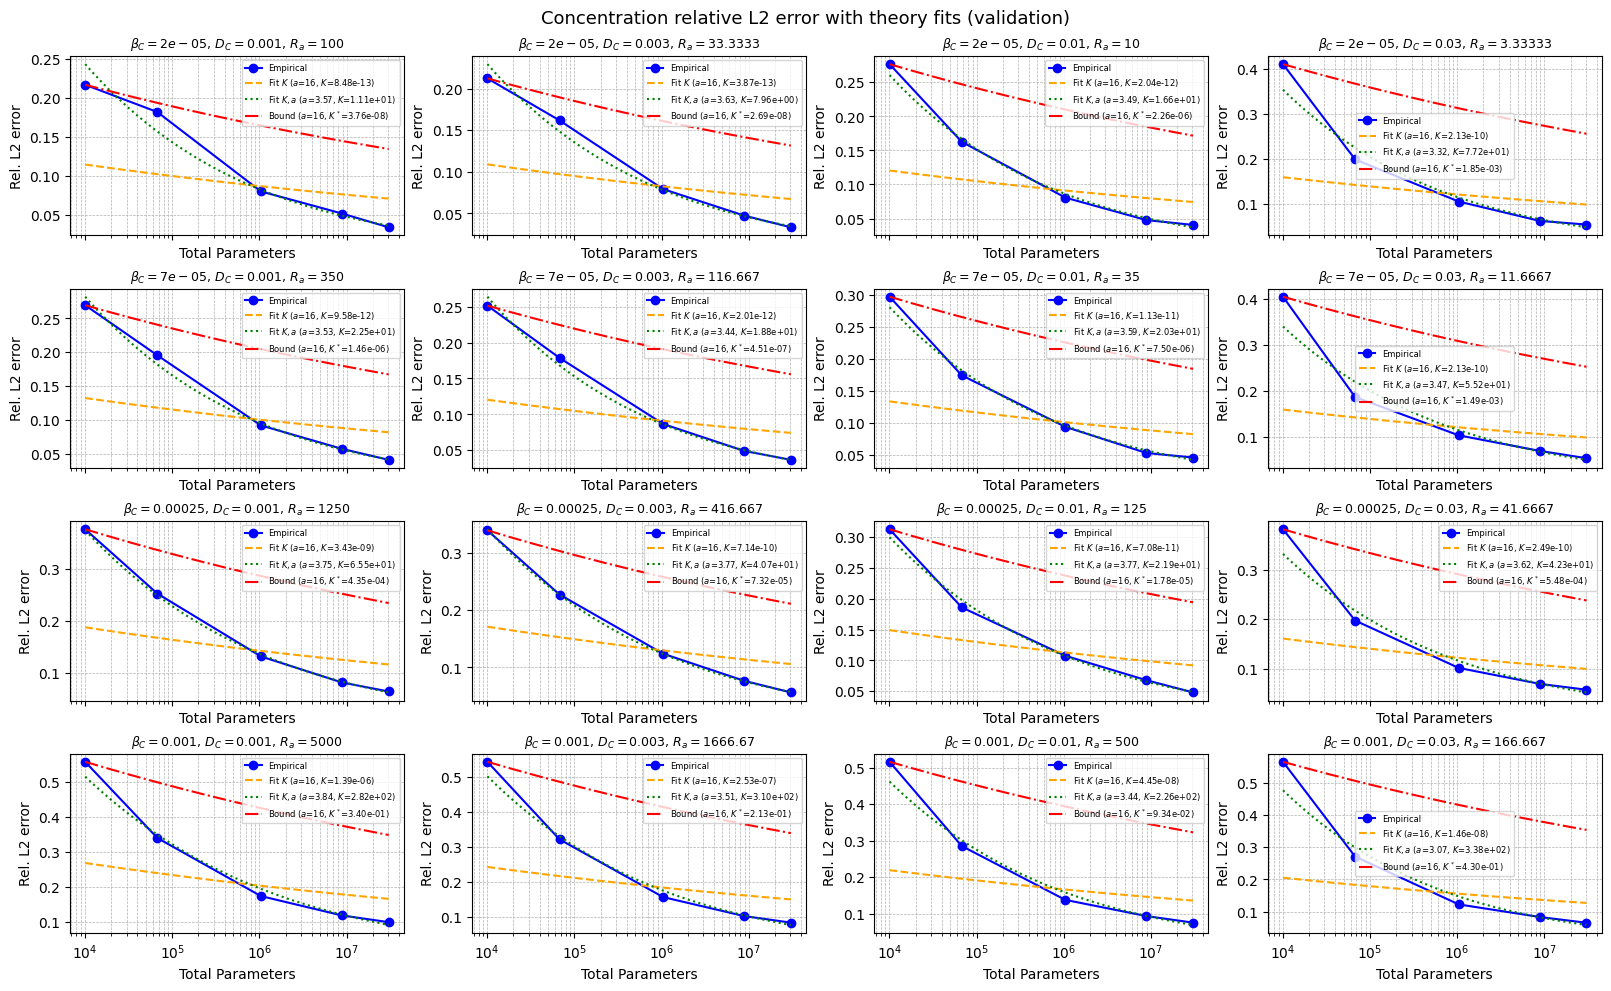

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,8.479242e-13,11.109593,3.571564,3.763123e-08
1,6,0.00002,0.003,33.333333,3.872275e-13,7.955688,3.626106,2.693464e-08
2,7,0.00002,0.010,10.000000,2.043648e-12,16.644885,3.494502,2.261422e-06
3,8,0.00002,0.030,3.333333,2.127368e-10,77.160136,3.316846,1.851421e-03
4,9,0.00007,0.001,350.000000,9.576317e-12,22.471997,3.531441,1.457493e-06
5,10,0.00007,0.003,116.666667,2.009086e-12,18.842861,3.441779,4.505303e-07
6,11,0.00007,0.010,35.000000,1.131534e-11,20.262434,3.594163,7.500469e-06
7,12,0.00007,0.030,11.666667,2.125171e-10,55.153861,3.474785,1.488030e-03
8,13,0.00025,0.001,1250.000000,3.430634e-09,65.453426,3.745123,4.346329e-04
9,14,0.00025,0.003,416.666667,7.142733e-10,40.668736,3.773145,7.319945e-05


In [37]:
fits_conc = scenario_grid("conc_rel_l2", "Rel. L2 error",
                          "Concentration relative L2 error with theory fits (validation)",
                          "theory_3a_conc_rel_l2.png", theory=True)
fits_conc

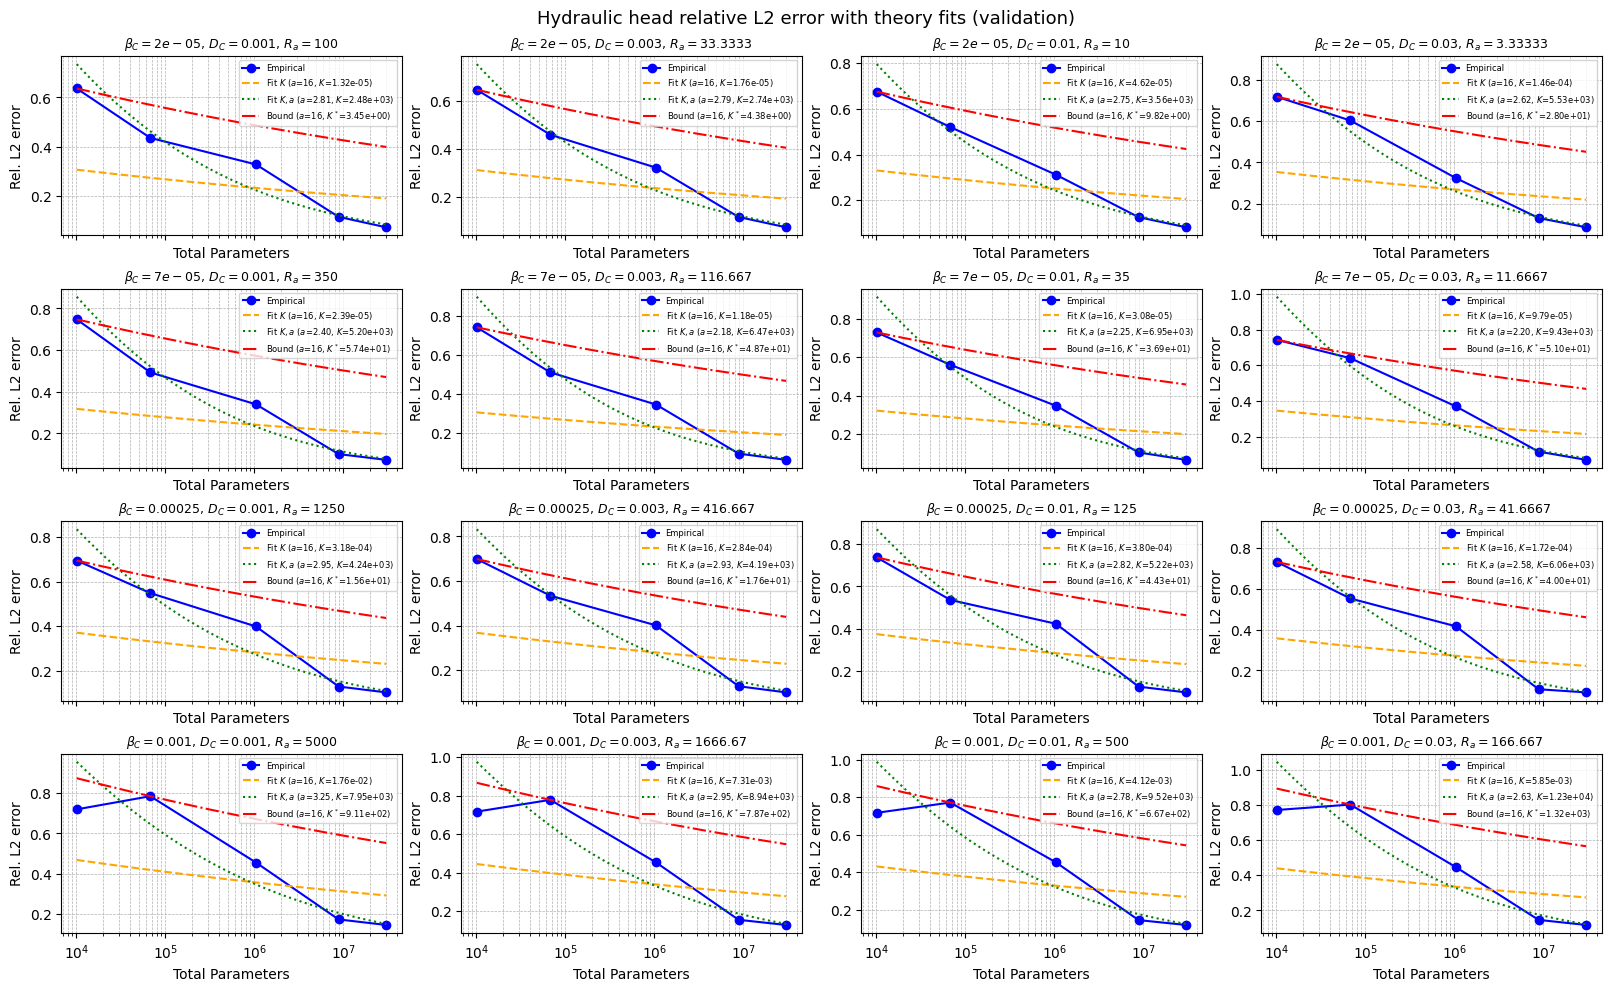

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,0.000013,2475.039751,2.813691,3.451876
1,6,0.00002,0.003,33.333333,0.000018,2743.863095,2.787805,4.376207
2,7,0.00002,0.010,10.000000,0.000046,3564.714699,2.753306,9.820683
3,8,0.00002,0.030,3.333333,0.000146,5527.300702,2.621112,28.012679
4,9,0.00007,0.001,350.000000,0.000024,5198.676332,2.404252,57.419520
5,10,0.00007,0.003,116.666667,0.000012,6474.573756,2.177553,48.676052
6,11,0.00007,0.010,35.000000,0.000031,6951.835401,2.249608,36.928528
7,12,0.00007,0.030,11.666667,0.000098,9430.771411,2.196327,51.020451
8,13,0.00025,0.001,1250.000000,0.000318,4237.024937,2.946274,15.623312
9,14,0.00025,0.003,416.666667,0.000284,4194.423668,2.934282,17.579358


In [38]:
fits_head = scenario_grid("head_rel_l2", "Rel. L2 error",
                          "Hydraulic head relative L2 error with theory fits (validation)",
                          "theory_3b_head_rel_l2.png", theory=True)
fits_head

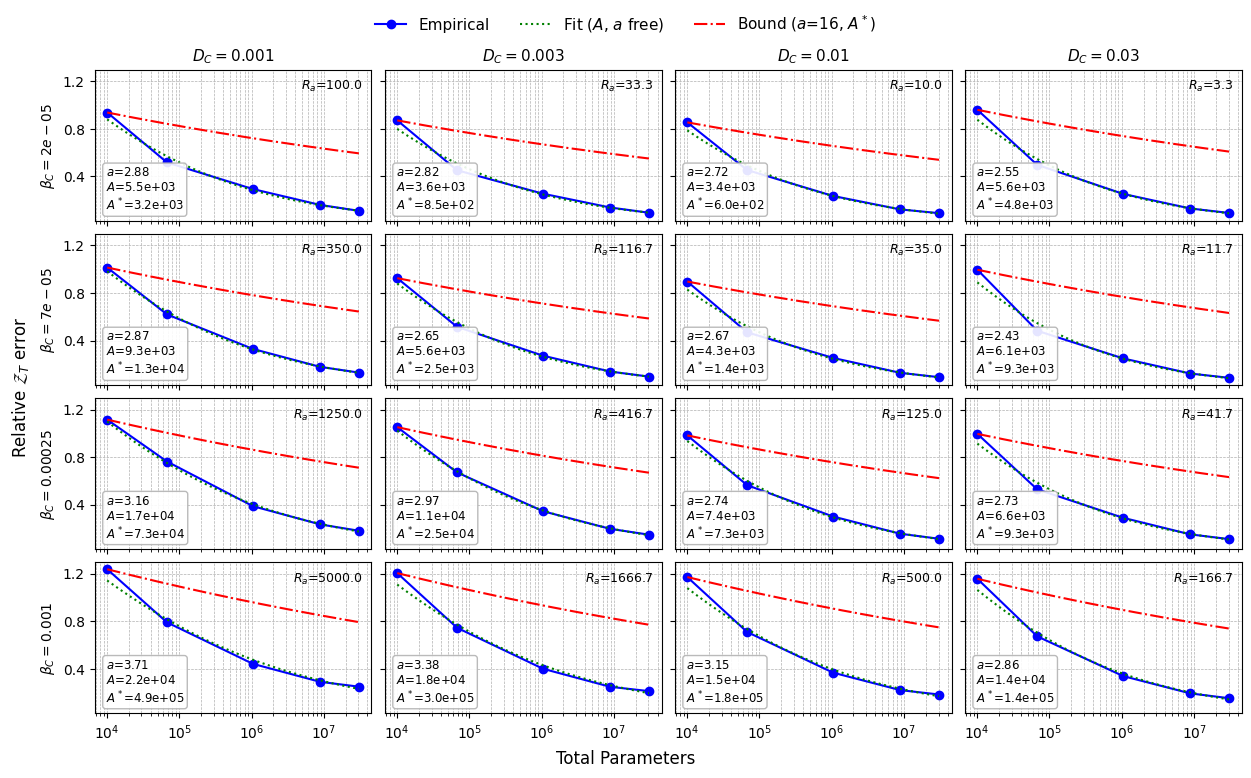

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,0.000707,5472.305338,2.878797,3152.801465
1,6,0.00002,0.003,33.333333,0.000078,3574.019273,2.822223,852.846330
2,7,0.00002,0.010,10.000000,0.000033,3417.785228,2.720690,604.254598
3,8,0.00002,0.030,3.333333,0.000111,5613.204735,2.553797,4832.013641
4,9,0.00007,0.001,350.000000,0.006362,9252.278552,2.866048,12916.689290
5,10,0.00007,0.003,116.666667,0.000208,5637.488877,2.649520,2467.933352
6,11,0.00007,0.010,35.000000,0.000069,4312.567415,2.670780,1413.583497
7,12,0.00007,0.030,11.666667,0.000071,6054.028710,2.434657,9278.213093
8,13,0.00025,0.001,1250.000000,0.236596,16540.805378,3.156278,72774.570933
9,14,0.00025,0.003,416.666667,0.023607,11275.718718,2.967018,25195.714670


In [39]:
fits_total = scenario_grid("total_norm", r"Relative $\mathcal{Z}_T$ error",
                           "Combined total-norm error with theory fits (validation)",
                           "theory_3c_total_norm.png", theory=True, paper=True)
fits_total

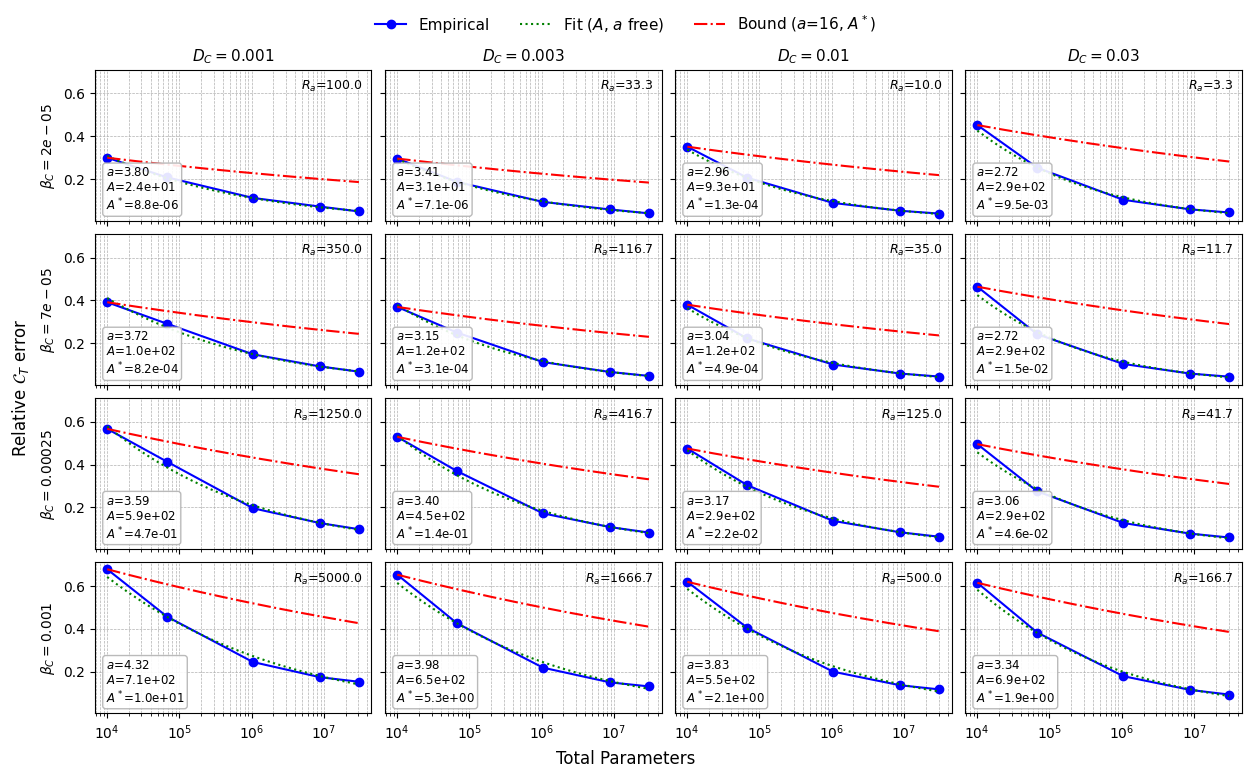

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,1.266999e-10,24.182792,3.799895,0.000009
1,6,0.00002,0.003,33.333333,1.179058e-11,31.179633,3.411242,0.000007
2,7,0.00002,0.010,10.000000,1.564437e-11,92.591874,2.964446,0.000130
3,8,0.00002,0.030,3.333333,2.640203e-10,289.051586,2.719633,0.009549
4,9,0.00007,0.001,350.000000,1.585604e-08,103.452593,3.720372,0.000819
5,10,0.00007,0.003,116.666667,3.144489e-10,122.087798,3.145165,0.000306
6,11,0.00007,0.010,35.000000,9.034327e-11,115.846087,3.037101,0.000490
7,12,0.00007,0.030,11.666667,2.394930e-10,285.853130,2.715189,0.014860
8,13,0.00025,0.001,1250.000000,4.723497e-06,589.676361,3.586515,0.465636
9,14,0.00025,0.003,416.666667,5.406339e-07,454.046652,3.399944,0.143704


In [40]:
fits_conc_norm = scenario_grid("conc_norm", r"Relative $\mathcal{C}_T$ error",
                               "Concentration component of the total norm with theory fits (validation)",
                               "theory_3d_conc_norm.png", theory=True, paper=True)
fits_conc_norm

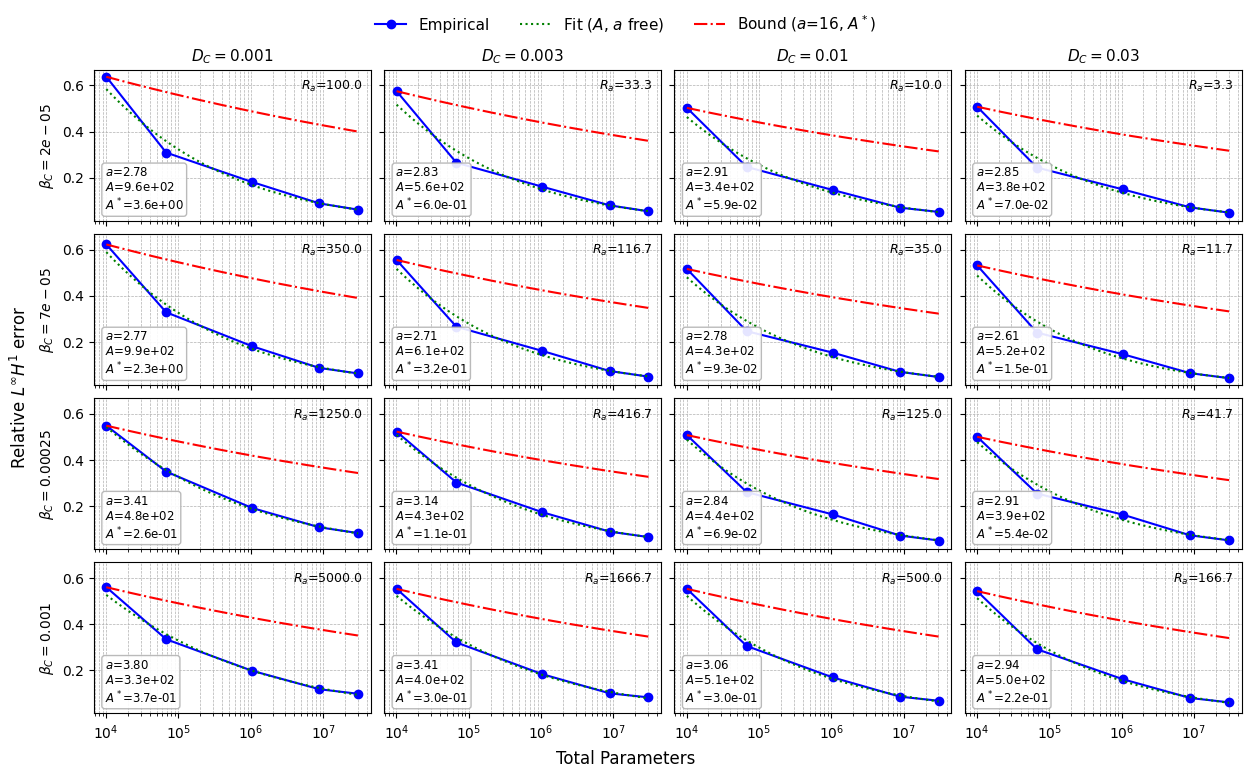

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,1.336087e-07,957.231536,2.775054,3.568958
1,6,0.00002,0.003,33.333333,1.822634e-08,564.790808,2.829774,0.597776
2,7,0.00002,0.010,10.000000,3.699431e-09,341.909323,2.910986,0.059227
3,8,0.00002,0.030,3.333333,3.332581e-09,378.560054,2.848290,0.069922
4,9,0.00007,0.001,350.000000,1.543860e-07,992.698398,2.772337,2.346650
5,10,0.00007,0.003,116.666667,8.792280e-09,608.908722,2.710221,0.323239
6,11,0.00007,0.010,35.000000,3.463022e-09,433.685189,2.783979,0.092636
7,12,0.00007,0.030,11.666667,1.579021e-09,523.315552,2.609881,0.153248
8,13,0.00025,0.001,1250.000000,7.539686e-07,482.218588,3.414456,0.263757
9,14,0.00025,0.003,416.666667,6.790884e-08,428.877353,3.141491,0.114680


In [41]:
fits_head_norm = scenario_grid("head_norm", r"Relative $L^\infty H^1$ error",
                               "Hydraulic head component of the total norm with theory fits (validation)",
                               "theory_3e_head_norm.png", theory=True, paper=True)
fits_head_norm

## 4. Fit parameters vs $\beta_C$

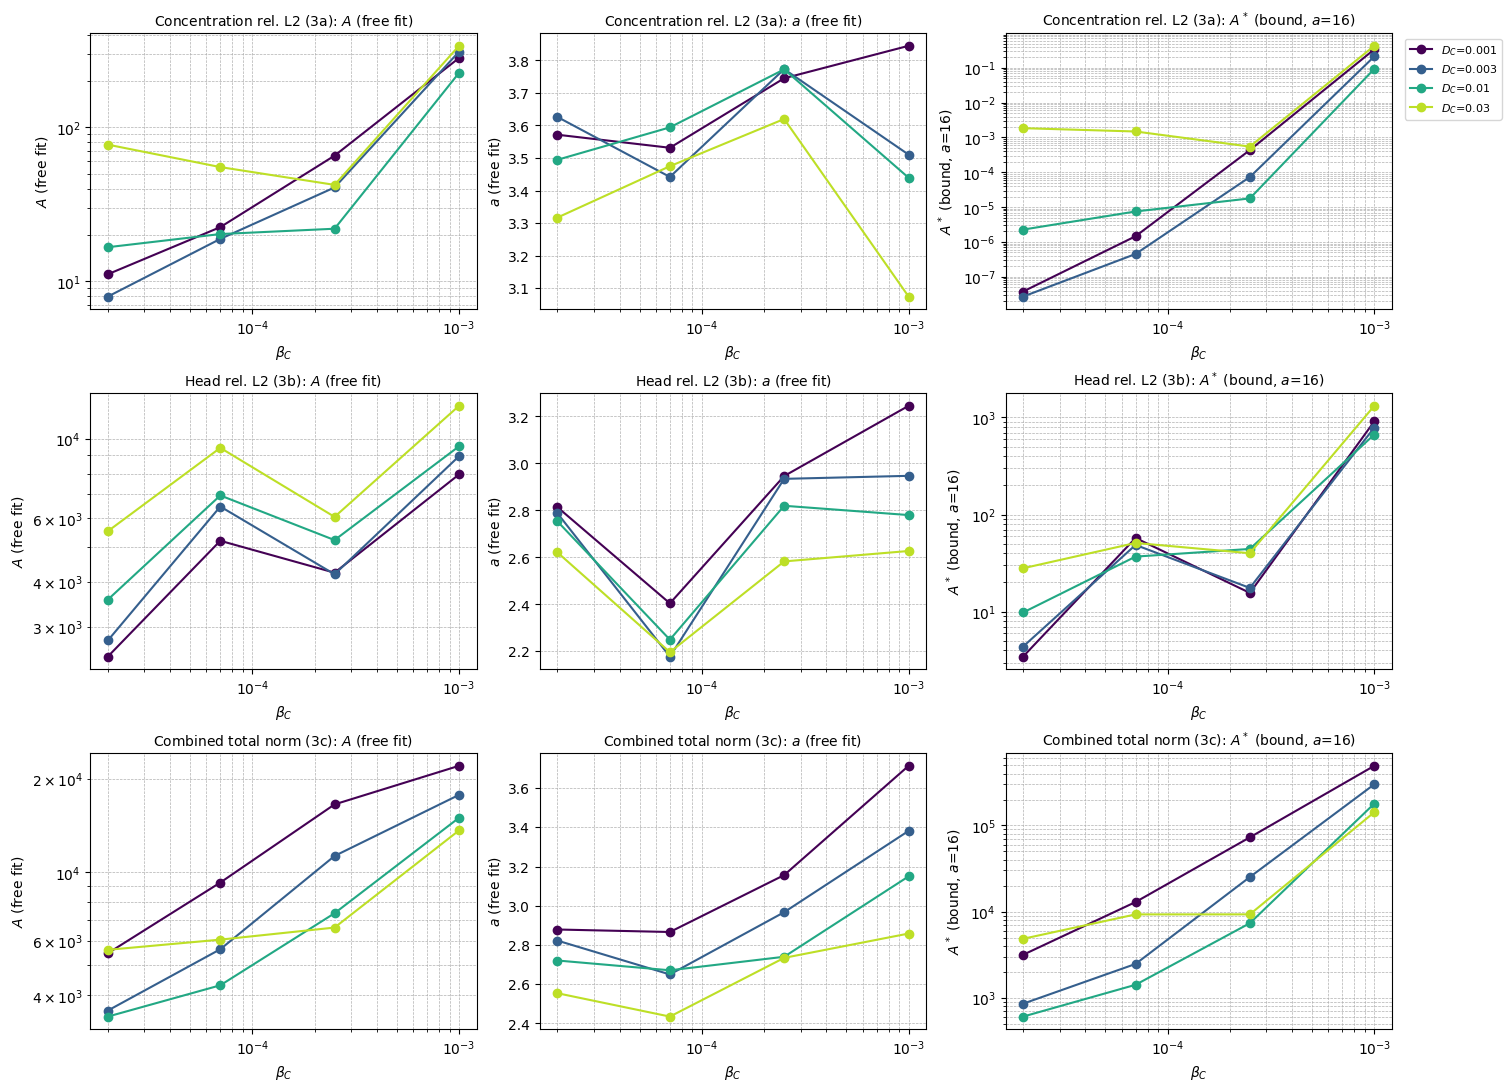

In [42]:
fit_sets = [("Concentration rel. L2 (3a)", fits_conc),
            ("Head rel. L2 (3b)", fits_head),
            ("Combined total norm (3c)", fits_total)]
param_cols = [("K_fit", "$A$ (free fit)", True),
              ("exponent_fit", "$a$ (free fit)", False),
              ("K_envelope", "$A^*$ (bound, $a$=16)", True)]

diffc_values = sorted(metrics_df["diffc"].unique())
diffc_colors = dict(zip(diffc_values, plt.cm.viridis(np.linspace(0, 0.9, len(diffc_values)))))

fig, axes = plt.subplots(len(fit_sets), len(param_cols), figsize=(15, 3.6 * len(fit_sets)),
                         constrained_layout=True, squeeze=False)

for row, (set_title, fdf) in enumerate(fit_sets):
    for col, (name, label, logy) in enumerate(param_cols):
        ax = axes[row, col]
        for diffc in diffc_values:
            sub = fdf[fdf["diffc"] == diffc].sort_values("beta_c")
            ax.plot(sub["beta_c"], sub[name], marker="o", color=diffc_colors[diffc], label=f"$D_C$={diffc:g}")
        ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        ax.set_xlabel("$\\beta_C$")
        ax.set_ylabel(label)
        ax.set_title(f"{set_title}: {label}", fontsize=10)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

axes[0, -1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.savefig(fig_dir / "fit_params_vs_beta_c.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

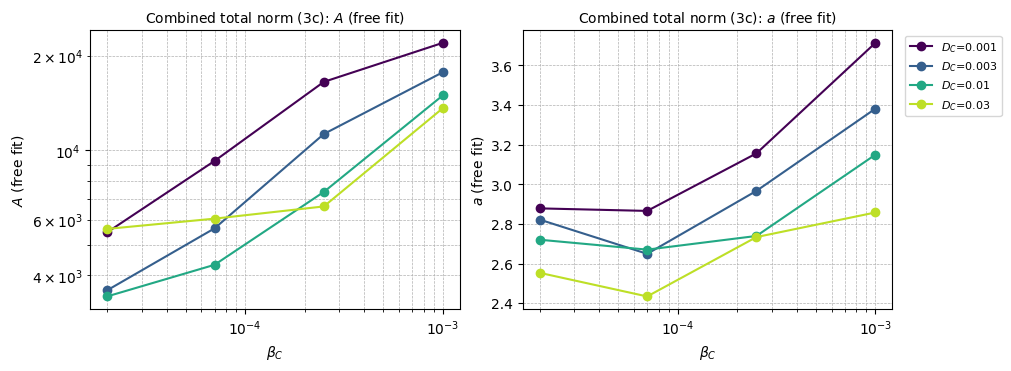

In [43]:
# --- Combined total norm (3c) only: A and a vs beta_C, colour = D_C ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)

for ax, (name, label, logy) in zip(axes, param_cols[:2]):
    for diffc in diffc_values:
        sub = fits_total[fits_total["diffc"] == diffc].sort_values("beta_c")
        ax.plot(sub["beta_c"], sub[name], marker="o", color=diffc_colors[diffc], label=f"$D_C$={diffc:g}")
    ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("$\\beta_C$")
    ax.set_ylabel(label)
    ax.set_title(f"Combined total norm (3c): {label}", fontsize=10)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

axes[-1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.savefig(fig_dir / "fit_params_vs_beta_c_total_norm.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

## 5. Paper figures

Saved as PNG and PDF in `figures/final/`. Uses `fits_total` (section 3) and `diffc_colors` (section 4).

In [44]:
PAPER_RC = {"font.size": 12, "axes.titlesize": 14, "axes.labelsize": 13, "xtick.labelsize": 11,
            "ytick.labelsize": 11, "legend.fontsize": 11}
MS, LW = 5, 1.8   # marker size / line width shared by the paper figures

beta_values = sorted(metrics_df["beta_c"].unique())
beta_colors = dict(zip(beta_values, plt.cm.plasma(np.linspace(0, 0.85, len(beta_values)))))


def save_paper_fig(fig, stem):
    fig.savefig(fig_dir / f"{stem}.png", bbox_inches="tight", dpi=300)
    fig.savefig(fig_dir / f"{stem}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

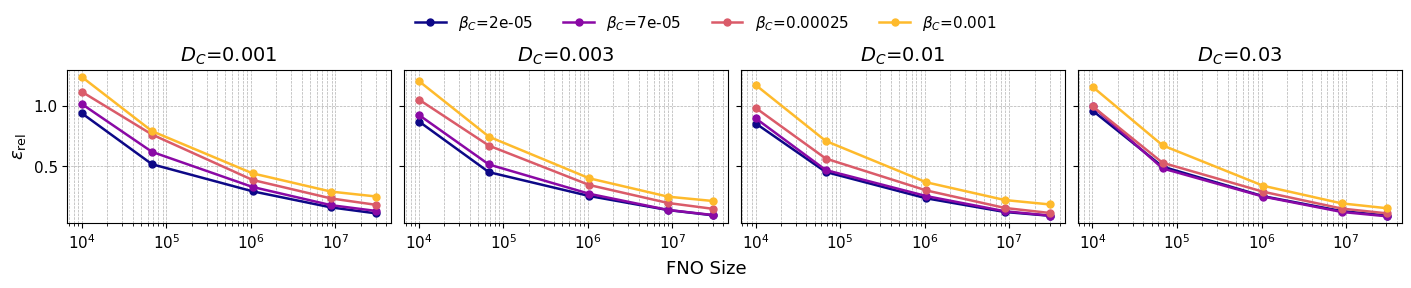

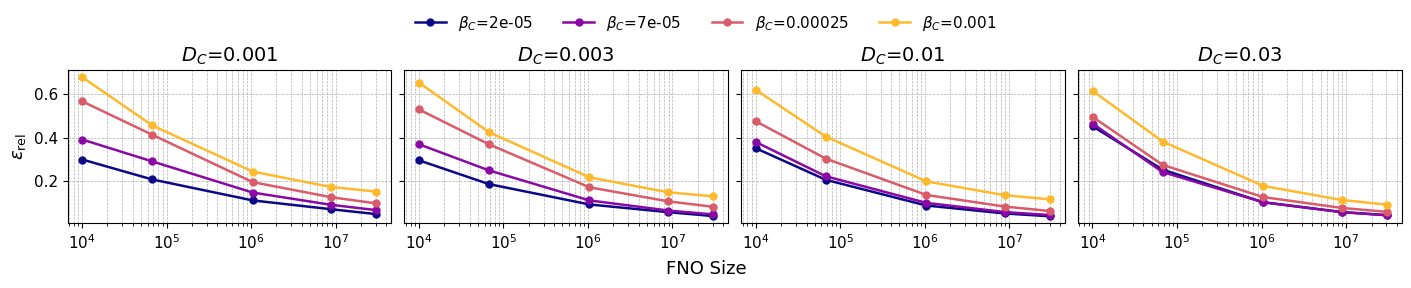

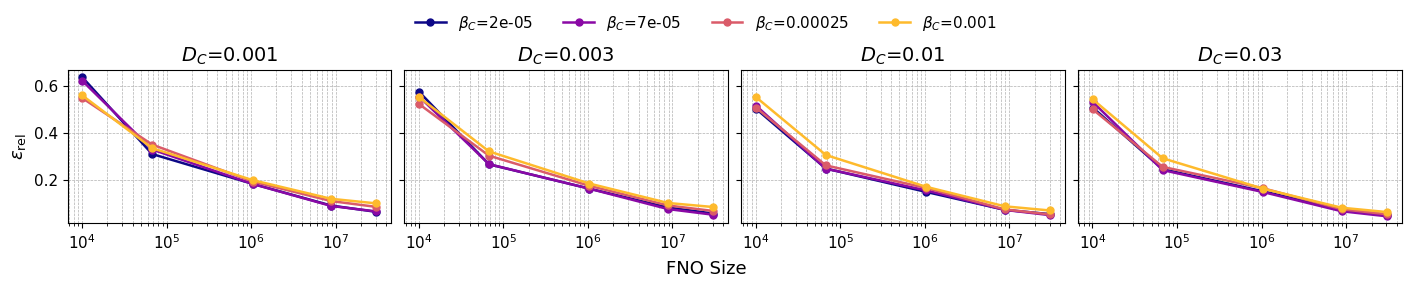

In [45]:
def plot_scaling_by_diffc(metric, stem, logy=False):
    """One panel per D_C, one line per beta_C: validation error vs FNO size."""
    with plt.rc_context(PAPER_RC):
        fig, axes = plt.subplots(1, len(diffc_values), figsize=(14.0, 2.8),
                                 sharex=True, sharey=True, constrained_layout=True)
        for ax, diffc in zip(axes, diffc_values):
            for beta_c in beta_values:
                sub = metrics_df.query("diffc == @diffc and beta_c == @beta_c").sort_values("total_params")
                ax.plot(sub["total_params"], sub[metric], marker="o", ms=MS, lw=LW,
                        color=beta_colors[beta_c], label=f"$\\beta_C$={beta_c:g}")
            ax.set_title(f"$D_C$={diffc:g}")
            ax.set_xscale("log")
            if logy:
                ax.set_yscale("log")
            ax.grid(True, which="both", linestyle="--", linewidth=0.5)

        axes[0].set_ylabel(r"$\varepsilon_{\text{rel}}$")
        fig.supxlabel("FNO Size", fontsize=13)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="outside upper center", ncol=len(beta_values), frameon=False, fontsize=11)
        save_paper_fig(fig, stem)


plot_scaling_by_diffc("total_norm", "paper_5e_total_scaling_by_diffc")   # Fig. 2 / Fig. 11
plot_scaling_by_diffc("conc_norm", "paper_5e_conc_scaling_by_diffc")     # Fig. 12a
plot_scaling_by_diffc("head_norm", "paper_5e_head_scaling_by_diffc")     # Fig. 12b

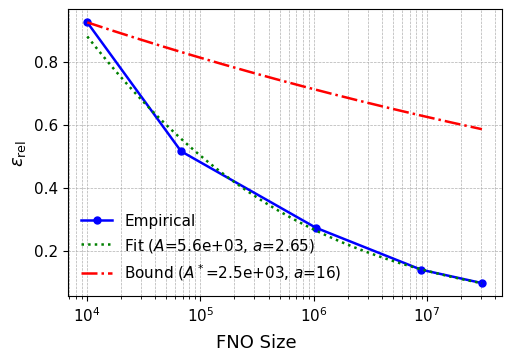

In [46]:
# Fig. 3 / Fig. 13: relative Z_T error for one scenario with free fit (green) and bound (red)
BETA_SINGLE, DIFFC_SINGLE = cfg["single_scenario"]

sub = metrics_df[np.isclose(metrics_df["beta_c"], BETA_SINGLE)
                 & np.isclose(metrics_df["diffc"], DIFFC_SINGLE)].sort_values("total_params")
if sub.empty:
    available = metrics_df[["beta_c", "diffc"]].drop_duplicates().sort_values(["beta_c", "diffc"])
    raise ValueError(f"No runs for beta_C={BETA_SINGLE:g}, D_C={DIFFC_SINGLE:g} in this dataset; "
                     f"available pairs:\n{available.to_string(index=False)}")
P, eps = sub["total_params"].to_numpy(), sub["total_norm"].to_numpy()

with plt.rc_context(PAPER_RC):
    fig, ax = plt.subplots(figsize=(5.0, 3.5), constrained_layout=True)
    ax.plot(P, eps, color="blue", marker="o", ms=MS, lw=LW, label="Empirical")
    fit = plot_theory_overlay(ax, P, eps, show_fixed=False)
    for line in ax.get_lines()[1:]:   # theory curves
        line.set_linewidth(LW)
    ax.set_xscale("log")
    ax.set_ylabel(r"$\varepsilon_{\text{rel}}$")
    ax.legend(handles=ax.get_lines(),
              labels=["Empirical",
                      f"Fit ($A$={fit['K_fit']:.1e}, $a$={fit['exponent_fit']:.2f})",
                      f"Bound ($A^*$={fit['K_envelope']:.1e}, $a$={THEORY_EXP})"],
              frameon=False)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    fig.supxlabel("FNO Size", fontsize=13)
    save_paper_fig(fig, f"theory_single_beta{BETA_SINGLE:g}_diffc{DIFFC_SINGLE:g}")

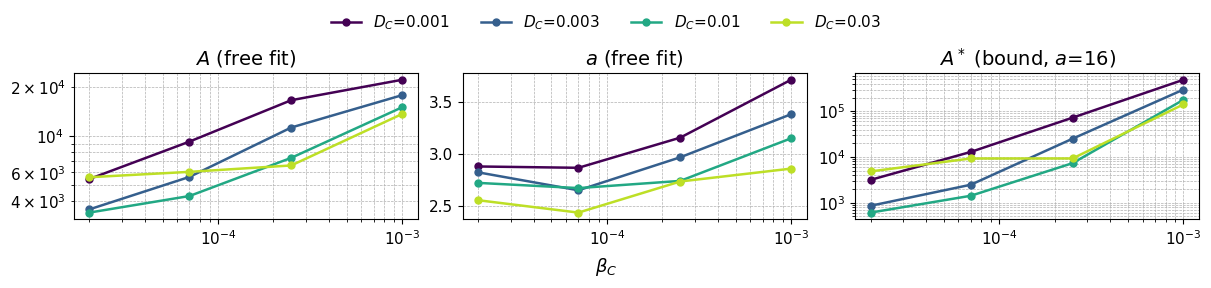

In [47]:
# Fig. 4: combined total norm (3c) fit parameters A, a, A* vs beta_C, colour = D_C
with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(1, len(param_cols), figsize=(12.0, 2.8), sharex=True, constrained_layout=True)

    for ax, (name, label, logy), tag in zip(axes, param_cols, ["(a)", "(b)", "(c)"]):
        for diffc in diffc_values:
            sub = fits_total[fits_total["diffc"] == diffc].sort_values("beta_c")
            ax.plot(sub["beta_c"], sub[name], marker="o", ms=MS, lw=LW, color=diffc_colors[diffc],
                    label=f"$D_C$={diffc:g}")
        ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        # ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    fig.supxlabel("$\\beta_C$", fontsize=13)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside upper center", ncol=len(diffc_values), frameon=False, fontsize=11)
    save_paper_fig(fig, "paper_fit_params_vs_beta_c_total_norm")

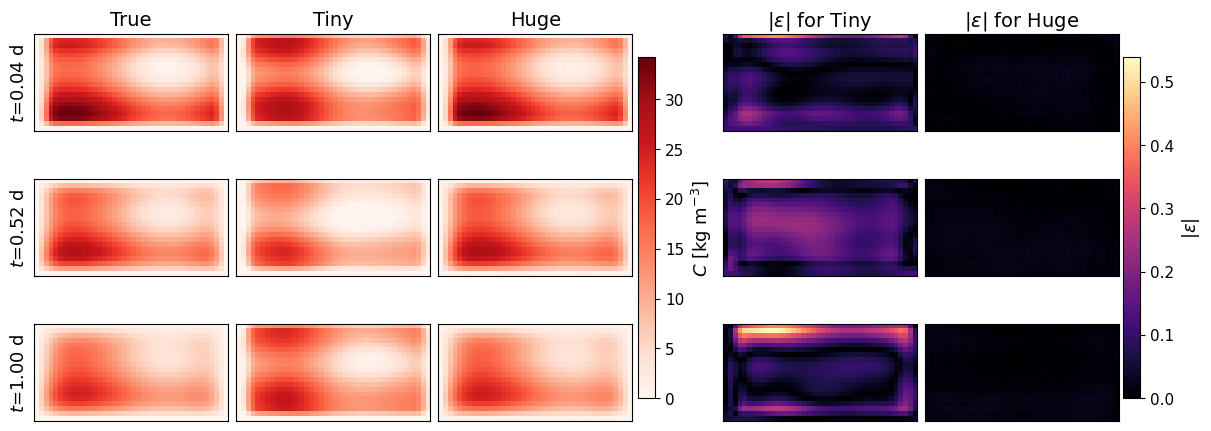

scenario 7: beta_C=2e-05, D_C=0.01, validation run 29


In [48]:
# Fig. 7 / Fig. 10: concentration snapshots of the validation run with the median largest-model error.
# Columns: true field, smallest and largest model predictions, and their errors relative to max(C).
SNAP_SIZES = ["tiny", "huge"]
SNAP_STEPS = [0, 12, 24]   # output indices, t = (k + 1) * DT

snap_beta, snap_diffc = cfg["snapshot_scenario"]
s = int(scenarios_df.loc[np.isclose(scenarios_df["beta_c"], snap_beta)
                         & np.isclose(scenarios_df["diffc"], snap_diffc), "scenario_index"].iloc[0])

snap_preds = {}
for size in SNAP_SIZES:
    with np.load(prediction_npz_dir / f"scenario_{s:03d}_{size}.npz") as data:
        snap_true = data["val_targets"][..., 0]
        snap_preds[size] = data["val_preds"][..., 0]
run = int(np.argsort(rel_l2(snap_true, snap_preds[SNAP_SIZES[-1]]))[len(snap_true) // 2])

truth = snap_true[run]
fields = [("True", truth)] + [(size.capitalize(), snap_preds[size][run]) for size in SNAP_SIZES]
# Relative to the max true concentration (pointwise |e|/C blows up where C = 0 in fresh water)
field_max = truth.max()
errors = [(rf"$|\epsilon|$ for {size.capitalize()}", np.abs(snap_preds[size][run] - truth) / field_max)
          for size in SNAP_SIZES]
err_max = max(e.max() for _, e in errors)
extent = [0, 2.0, 0, 1.0]

with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(len(SNAP_STEPS), len(fields) + len(errors), figsize=(12.0, 4.4),
                             constrained_layout=True, squeeze=False)
    for row, k in enumerate(SNAP_STEPS):
        for col, (title, arr) in enumerate(fields + errors):
            ax = axes[row, col]
            is_err = col >= len(fields)
            im = ax.imshow(arr[k], extent=extent, cmap="magma" if is_err else "Reds",
                           vmin=0, vmax=err_max if is_err else field_max)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(title)
            if col == 0:
                ax.set_ylabel(f"$t$={(k + 1) * DT:.2f} d")
            if row == len(SNAP_STEPS) - 1:
                if col == len(fields) - 1:
                    field_im = im
                elif is_err:
                    err_im = im
    fig.colorbar(field_im, ax=axes[:, :len(fields)], shrink=0.8, pad=0.01, label="$C$ [kg m$^{-3}$]")
    fig.colorbar(err_im, ax=axes[:, len(fields):], shrink=0.8, pad=0.01, label=r"$|\epsilon|$")
    save_paper_fig(fig, "paper_5d_snapshots")
print(f"scenario {s}: beta_C={snap_beta:g}, D_C={snap_diffc:g}, validation run {run}")

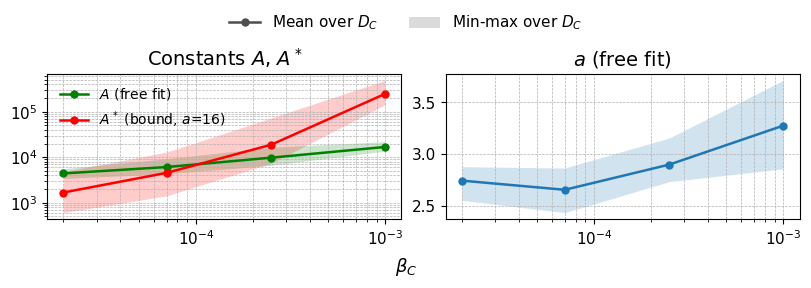

K_fit                                 K_envelope  \
                 mean           min           max           mean   
beta_c                                                             
0.00002   4401.196063   3417.785228   5613.204735    1673.897578   
0.00007   6074.753958   4312.567415   9252.278552    4521.865207   
0.00025   9766.799283   6622.571562  16540.805378   18797.463676   
0.00100  16809.153530  13630.310234  22032.910344  247933.175843   

                                      exponent_fit                      
                   min            max         mean       min       max  
beta_c                                                                  
0.00002     604.254598    4832.013641     2.743877  2.553797  2.878797  
0.00007    1413.583497   12916.689290     2.655251  2.434657  2.866048  
0.00025    7331.690445   72774.570933     2.899284  2.734106  3.156278  
0.00100  142392.072349  492564.981863     3.275855  2.858170  3.713685

In [49]:
# Backup (not in the paper): (left) A and A*, (right) a, vs one parameter, averaged over the other (3c)
# Constants: geometric mean (they span decades, log y-axis). Rate a: arithmetic mean (linear y-axis).
# Band = min-max over the averaged parameter. Colours match the theory overlays: green = free fit, red = bound.
CONST_PARAMS = [("K_fit", "$A$ (free fit)", "green"),
                ("K_envelope", f"$A^*$ (bound, $a$={THEORY_EXP})", "red")]


def plot_params_averaged(x_col, x_label, avg_label, stem):
    names = [name for name, _, _ in CONST_PARAMS]
    const = 10 ** (np.log10(fits_total[names]).groupby(fits_total[x_col]).agg(["mean", "min", "max"]))
    rate = fits_total.groupby(x_col)[["exponent_fit"]].agg(["mean", "min", "max"])["exponent_fit"]

    with plt.rc_context(PAPER_RC):
        fig, axes = plt.subplots(1, 2, figsize=(8.0, 2.8), sharex=True, constrained_layout=True)

        ax = axes[0]
        for name, label, color in CONST_PARAMS:
            ax.plot(const.index, const[(name, "mean")], marker="o", ms=MS, lw=LW, color=color, label=label)
            ax.fill_between(const.index, const[(name, "min")], const[(name, "max")], color=color, alpha=0.2, lw=0)
        ax.set_yscale("log")
        ax.set_title("Constants $A$, $A^*$")
        ax.legend(loc="upper left", frameon=False, fontsize=10)

        ax = axes[1]
        ax.plot(rate.index, rate["mean"], marker="o", ms=MS, lw=LW, color="tab:blue")
        ax.fill_between(rate.index, rate["min"], rate["max"], color="tab:blue", alpha=0.2, lw=0)
        ax.set_title("$a$ (free fit)")

        for ax in axes:
            ax.set_xscale("log")
            ax.grid(True, which="both", linestyle="--", linewidth=0.5)
        fig.supxlabel(x_label, fontsize=13)
        fig.legend(handles=[Line2D([], [], color="0.3", marker="o", ms=MS, lw=LW,
                                   label=f"Mean over {avg_label}"),
                            plt.Rectangle((0, 0), 1, 1, color="0.3", alpha=0.2, lw=0,
                                          label=f"Min-max over {avg_label}")],
                   loc="outside upper center", ncol=2, frameon=False, fontsize=11)
        save_paper_fig(fig, stem)
    return const.join(pd.concat({"exponent_fit": rate}, axis=1))


plot_params_averaged("beta_c", "$\\beta_C$", "$D_C$", "paper_fit_params_vs_beta_c_avg_diffc")

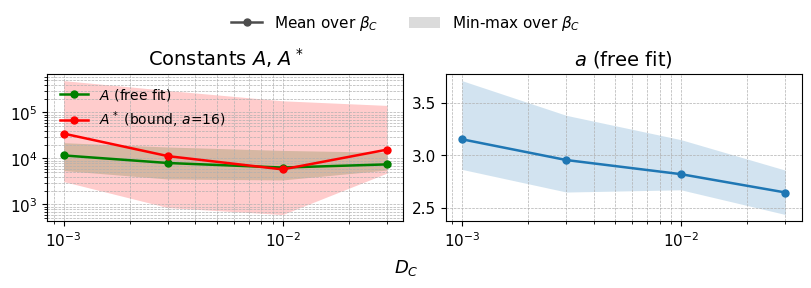

K_fit                               K_envelope               \
               mean          min           max          mean          min   
diffc                                                                       
0.001  11654.989456  5472.305338  22032.910344  34759.438779  3152.801465   
0.003   7969.023801  3574.019273  17751.443483  11234.131730   852.846330   
0.010   6350.143889  3417.785228  14975.181463   5789.311347   604.254598   
0.030   7442.124651  5613.204735  13630.310234  15604.189533  4832.013641   

                     exponent_fit                      
                 max         mean       min       max  
diffc                                                  
0.001  492564.981863     3.153702  2.866048  3.713685  
0.003  300349.666895     2.955132  2.649520  3.381769  
0.010  179375.066583     2.820250  2.670780  3.149798  
0.030  142392.072349     2.645183  2.434657  2.858170

In [50]:
# Backup (not in the paper): A, A* and a (3c) vs D_C, averaged over beta_C
plot_params_averaged("diffc", "$D_C$", "$\\beta_C$", "paper_fit_params_vs_diffc_avg_beta_c")